<a href="https://colab.research.google.com/github/sahit1011/AI-Coding-Session/blob/main/train_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning SDXL to the Naruto art style — **v2** (free Colab T4, 16GB)

LoRA fine-tune of [`stabilityai/stable-diffusion-xl-base-1.0`](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0)
on [`lambdalabs/naruto-blip-captions`](https://huggingface.co/datasets/lambdalabs/naruto-blip-captions).

**v1 trained successfully but its adapter was over-strong**: at full LoRA weight it
imposed a magenta colour cast and washed-out contrast, and was only usable at
`lora_scale=0.5`. v2 fixes that at the source. The **memory strategy is unchanged** —
that part worked (10.39GB peak on a 16GB T4).

| # | Change from v1 | Why |
|---|---|---|
| 1 | `cond_resolution = 1024` (new) | v1 wrote each image's **true** source size (512px) into SDXL's `original_size` micro-conditioning, while the inference pipeline sends 1024 — so it trained in a conditioning region inference never visits. v2 writes one uniform value that matches inference, crops fixed at (0,0). |
| 2 | `lora_alpha 4` with `rank 8` (was 8/8) | LoRA scaling is `alpha/rank`, so the adapter now applies **0.5 internally** — the strength v1 had to be dialled down to by hand is baked in, and `lora_scale=1.0` is correct at inference. |
| 3 | `snr_gamma = 0` (was 5.0) | min-SNR weighting relatively up-weights **high-noise** timesteps, which is where a diffusion model encodes global **colour** rather than detail — the prime suspect for v1's colour drift. |
| 4 | `600` steps (was 1200) | v1's validation strip showed the style established by ~step 400; the back half mostly deepened the colour bias. |
| 5 | `caption_dropout = 0.1` (new) | Trains a genuine unconditional distribution, so classifier-free guidance has something honest to extrapolate from. |
| 6 | keep **all 6** checkpoints (was last 3) | v1 kept only steps 1000–1200, so there was no way to fall back to an earlier, less colour-biased adapter. |

The VRAM techniques (LoRA on attention only, precomputed latents + text embeddings,
gradient checkpointing, 8-bit AdamW, fp16, batch-1 + accumulation) are all as in v1 —
see the repo README for the full rationale.

**Before running:** `Runtime → Change runtime type → T4 GPU`. Expect ~8 min precompute
(a *new* cache: the conditioning changed) and **~55 min** of training.

> Set `smoke_test = True` first for a ~5-minute end-to-end check.

In [1]:
!nvidia-smi

# NOTE: bitsandbytes must be >=0.45.3. Older builds import `triton.ops`, which was
# removed in triton 3.x (preinstalled on current Colab), so diffusers' lazy import of
# its bitsandbytes quantizer dies with "No module named 'triton.ops'".
%pip install -q diffusers==0.31.0 peft==0.13.2 "bitsandbytes>=0.45.3" \
    "transformers>=4.46" "accelerate>=1.1" "datasets>=3.1" "safetensors>=0.4.4"

Thu Aug 20 07:51:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

> **If the cell above installed/upgraded anything, restart the runtime now**
> (`Runtime → Restart session`) and continue from the next cell — Colab keeps the
> old modules in memory otherwise. The check below must print without error before
> you go on.

In [2]:
import bitsandbytes, torch, triton
from diffusers.models.autoencoders.autoencoder_kl import AutoencoderKL  # the import that fails on old bnb

print("torch        ", torch.__version__)
print("triton       ", triton.__version__)
print("bitsandbytes ", bitsandbytes.__version__, "(needs >= 0.45.3)")
print("CUDA device  ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU - set Runtime > T4")
print("\nenvironment OK")

torch         2.11.0+cu128
triton        3.6.0
bitsandbytes  0.50.1 (needs >= 0.45.3)
CUDA device   Tesla T4

environment OK


## 1 · Configuration

Everything tunable lives here. `resolution` 768 is the T4 sweet spot (the source images are 512px, SDXL is 1024-native — 768 is the compromise); drop to **512** for ~2× faster steps if you want more optimizer steps inside the 5h Colab window.

In [3]:
import gc, json, logging, math, os, time
from dataclasses import dataclass
from pathlib import Path

# Set before CUDA init: reduces fragmentation-driven OOMs.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


@dataclass
class Config:
    pretrained_model: str = "stabilityai/stable-diffusion-xl-base-1.0"
    vae_model: str = "madebyollin/sdxl-vae-fp16-fix"   # fp16-safe VAE for encoding
    dataset_name: str = "lambdalabs/naruto-blip-captions"
    resolution: int = 768          # 512 also supported: ~2x faster/step, softer detail
    cond_resolution: int = 1024    # SDXL original_size/target_size written for EVERY sample.
                                   # Match what you GENERATE at (pipeline default 1024), not
                                   # the training resolution. v1 wrote the true 512 and so
                                   # trained where inference never looks.
    caption_suffix: str = ", naruto style"  # style trigger appended to every caption
    caption_dropout: float = 0.1   # fraction of captions replaced by the empty prompt
    rank: int = 8                  # LoRA rank
    lora_alpha: int = 4            # scaling = alpha/rank = 0.5, baked into the adapter
    learning_rate: float = 1e-4
    lr_warmup_steps: int = 100
    max_train_steps: int = 600     # optimizer steps; each sees batch*accum images
    train_batch_size: int = 1
    gradient_accumulation_steps: int = 4
    max_grad_norm: float = 1.0
    snr_gamma: float = 0.0         # min-SNR off in v2: it up-weights the high-noise
                                   # timesteps where global colour is learned
    seed: int = 42
    use_8bit_adam: bool = True
    checkpointing_steps: int = 100   # ~9 min of work at risk per disconnect, ~2% overhead
    checkpoints_total_limit: int = 6   # keep ALL of them, so an earlier one stays reachable
    validation_steps: int = 100    # one preview per checkpoint, so each is judgeable
    num_inference_steps_val: int = 20
    log_every: int = 10
    resume: str = "latest"         # "latest" | checkpoint path | "" for fresh start
    smoke_test: bool = False       # True: 20 steps on 64 images to validate end-to-end

cfg = Config()
if cfg.smoke_test:
    cfg.max_train_steps, cfg.checkpointing_steps, cfg.validation_steps = 20, 10, 10

# ---- storage: Google Drive so nothing is lost on disconnect ----
USE_DRIVE = True
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/naruto-sdxl-lora-v2")
else:
    ROOT = Path("naruto-sdxl-lora-v2-runs")  # local / Kaggle fallback

OUTPUT_DIR = ROOT / ("outputs-smoke" if cfg.smoke_test else "outputs")
CACHE_DIR = ROOT / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def setup_logging(output_dir):
    logger = logging.getLogger("train")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
    for h in (logging.StreamHandler(), logging.FileHandler(output_dir / "train_log.txt", mode="a")):
        h.setFormatter(fmt)
        logger.addHandler(h)
    return logger


def vram_gb():
    return torch.cuda.max_memory_allocated() / 2**30 if torch.cuda.is_available() else 0.0


logger = setup_logging(OUTPUT_DIR)
logger.info(f"config: {cfg}")
print("outputs ->", OUTPUT_DIR)
print("cache   ->", CACHE_DIR)

Mounted at /content/drive


2026-08-20 07:53:50 | config: Config(pretrained_model='stabilityai/stable-diffusion-xl-base-1.0', vae_model='madebyollin/sdxl-vae-fp16-fix', dataset_name='lambdalabs/naruto-blip-captions', resolution=768, cond_resolution=1024, caption_suffix=', naruto style', caption_dropout=0.1, rank=8, lora_alpha=4, learning_rate=0.0001, lr_warmup_steps=100, max_train_steps=600, train_batch_size=1, gradient_accumulation_steps=4, max_grad_norm=1.0, snr_gamma=0.0, seed=42, use_8bit_adam=True, checkpointing_steps=100, checkpoints_total_limit=6, validation_steps=100, num_inference_steps_val=20, log_every=10, resume='latest', smoke_test=False)
INFO:train:config: Config(pretrained_model='stabilityai/stable-diffusion-xl-base-1.0', vae_model='madebyollin/sdxl-vae-fp16-fix', dataset_name='lambdalabs/naruto-blip-captions', resolution=768, cond_resolution=1024, caption_suffix=', naruto style', caption_dropout=0.1, rank=8, lora_alpha=4, learning_rate=0.0001, lr_warmup_steps=100, max_train_steps=600, train_batch_

outputs -> /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs
cache   -> /content/drive/MyDrive/naruto-sdxl-lora-v2/cache


## 2 · Phase 1 — precompute VAE latents + text embeddings

The single biggest VRAM win. We push every image through the (fp16-fix) VAE **once** and every caption through **both** CLIP text encoders **once**, then cache the results to Drive (~0.6GB at 768px). During training, neither the VAE nor the text encoders exist in GPU memory at all — the training loop holds only the UNet.

This also means the (cheap) data pipeline can be debugged without burning training quota: the cell is a no-op re-run once the cache exists.

In [4]:
VALIDATION_PROMPTS = [
    "a boy with blue eyes, naruto style",
    "a man with red hair eating ramen, naruto style",
]


@torch.no_grad()
def encode_prompts(texts, tokenizers, text_encoders, device, dtype, batch_size=64):
    # SDXL conditioning: concat penultimate hidden states of both CLIP encoders
    # (77x2048) + pooled projection of the big encoder (1280).
    all_embeds, all_pooled = [], []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i + batch_size]
        embeds, pooled = [], None
        for tok, enc in zip(tokenizers, text_encoders):
            ids = tok(chunk, padding="max_length", max_length=tok.model_max_length,
                      truncation=True, return_tensors="pt").input_ids.to(device)
            out = enc(ids, output_hidden_states=True)
            pooled = out[0]  # CLIPTextModelWithProjection: pooled projection
            embeds.append(out.hidden_states[-2])
        all_embeds.append(torch.cat(embeds, dim=-1).to(dtype).cpu())
        all_pooled.append(pooled.to(dtype).cpu())
    return torch.cat(all_embeds), torch.cat(all_pooled)


@torch.no_grad()
def precompute_cache(cfg, cache_path, logger):
    import numpy as np
    from datasets import load_dataset
    from diffusers import AutoencoderKL
    from PIL import Image
    from transformers import AutoTokenizer, CLIPTextModel, CLIPTextModelWithProjection

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float16 if device.type == "cuda" else torch.float32
    res = cfg.resolution

    ds = load_dataset(cfg.dataset_name, split="train")
    logger.info(f"[precompute] {len(ds)} image-caption pairs")

    cond = cfg.cond_resolution

    def prep_image(img):
        # resize shorter side -> res, center-crop, then emit UNIFORM SDXL
        # micro-conditioning: (cond, cond, 0, 0, cond, cond) for every sample.
        # The dataset is uniformly 512px so the true size carries no signal; what
        # matters is that training matches what the pipeline sends at inference.
        img = img.convert("RGB")
        w0, h0 = img.size
        scale = res / min(w0, h0)
        w1, h1 = max(res, round(w0 * scale)), max(res, round(h0 * scale))
        img = img.resize((w1, h1), Image.BICUBIC)
        left, top = (w1 - res) // 2, (h1 - res) // 2
        img = img.crop((left, top, left + res, top + res))
        px = torch.from_numpy(np.asarray(img).copy()).permute(2, 0, 1).float() / 127.5 - 1.0
        return px, [cond, cond, 0, 0, cond, cond]

    logger.info(f"[precompute] encoding images at {res}px with fp16-fix VAE ...")
    vae = AutoencoderKL.from_pretrained(cfg.vae_model, torch_dtype=dtype).to(device).eval()
    scaling = vae.config.scaling_factor

    latents, time_ids, batch_px, bs, t0 = [], [], [], 8, time.time()
    for i, ex in enumerate(ds):
        px, tid = prep_image(ex["image"])
        batch_px.append(px)
        time_ids.append(tid)
        if len(batch_px) == bs or i == len(ds) - 1:
            pixels = torch.stack(batch_px).to(device, dtype=dtype)
            lat = vae.encode(pixels).latent_dist.sample() * scaling
            latents.append(lat.to(torch.float16).cpu())
            batch_px = []
            if (i + 1) % 256 == 0:
                logger.info(f"[precompute]   {i + 1}/{len(ds)} images ({time.time() - t0:.0f}s)")
    latents = torch.cat(latents)
    del vae; gc.collect(); torch.cuda.empty_cache()

    logger.info("[precompute] encoding captions with both CLIP text encoders ...")
    tokenizers = [
        AutoTokenizer.from_pretrained(cfg.pretrained_model, subfolder="tokenizer"),
        AutoTokenizer.from_pretrained(cfg.pretrained_model, subfolder="tokenizer_2"),
    ]
    text_encoders = [
        CLIPTextModel.from_pretrained(cfg.pretrained_model, subfolder="text_encoder",
                                      torch_dtype=dtype).to(device).eval(),
        CLIPTextModelWithProjection.from_pretrained(cfg.pretrained_model, subfolder="text_encoder_2",
                                                    torch_dtype=dtype).to(device).eval(),
    ]
    captions = [t + cfg.caption_suffix for t in ds["text"]]
    prompt_embeds, pooled_embeds = encode_prompts(captions, tokenizers, text_encoders, device, torch.float16)
    val_embeds, val_pooled = encode_prompts(VALIDATION_PROMPTS, tokenizers, text_encoders, device, torch.float16)
    uncond_embeds, uncond_pooled = encode_prompts([""], tokenizers, text_encoders, device, torch.float16)
    del text_encoders, tokenizers; gc.collect(); torch.cuda.empty_cache()

    cache = {
        "meta": {"dataset": cfg.dataset_name, "resolution": res,
                 "cond_resolution": cond,
                 "caption_suffix": cfg.caption_suffix, "num_samples": len(ds)},
        "latents": latents,                                       # (N,4,res/8,res/8) fp16
        "prompt_embeds": prompt_embeds,                           # (N,77,2048) fp16
        "pooled_embeds": pooled_embeds,                           # (N,1280) fp16
        "time_ids": torch.tensor(time_ids, dtype=torch.float16),  # (N,6)
        "val": {"prompts": VALIDATION_PROMPTS,
                "prompt_embeds": val_embeds, "pooled_embeds": val_pooled,
                "uncond_embeds": uncond_embeds, "uncond_pooled": uncond_pooled},
    }
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(cache, cache_path)
    logger.info(f"[precompute] cache saved: {cache_path} ({cache_path.stat().st_size / 2**20:.0f} MB)")
    return cache


# conditioning is part of the cache CONTENTS, so it is part of the filename
cache_path = CACHE_DIR / f"naruto_{cfg.resolution}px_cond{cfg.cond_resolution}.pt"
if cache_path.exists():
    logger.info(f"[precompute] reusing cache {cache_path}")
    cache = torch.load(cache_path, map_location="cpu", weights_only=True)
    assert cache["meta"]["caption_suffix"] == cfg.caption_suffix, \
        f"cache built with different caption_suffix - delete {cache_path} to rebuild"
else:
    cache = precompute_cache(cfg, cache_path, logger)

if cfg.smoke_test:  # tiny in-memory slice; the full cache file stays intact
    for k in ["latents", "prompt_embeds", "pooled_embeds", "time_ids"]:
        cache[k] = cache[k][:64]

print("latents      :", tuple(cache["latents"].shape), cache["latents"].dtype)
print("prompt_embeds:", tuple(cache["prompt_embeds"].shape))
print("pooled_embeds:", tuple(cache["pooled_embeds"].shape))
print("time_ids     :", tuple(cache["time_ids"].shape))

README.md:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…): reconstructing file:   0%|          |  0.00B /  344MB            

data/train-00000-of-00002-12944970063701(…): downloading bytes:           |  0.00B            

...

text_encoder_2/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.78GB            

text_encoder_2/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

2026-08-20 08:02:07 | [precompute] cache saved: /content/drive/MyDrive/naruto-sdxl-lora-v2/cache/naruto_768px_cond1024.pt (457 MB)
INFO:train:[precompute] cache saved: /content/drive/MyDrive/naruto-sdxl-lora-v2/cache/naruto_768px_cond1024.pt (457 MB)


latents      : (1221, 4, 96, 96) torch.float16
prompt_embeds: (1221, 77, 2048)
pooled_embeds: (1221, 1280)
time_ids     : (1221, 6)


## 3 · Phase 2 — model setup: frozen fp16 UNet + fp32 LoRA + 8-bit AdamW

Only the UNet is loaded (≈5.1GB in fp16, frozen). LoRA adapters go on the attention projections (`to_q/k/v/out`); they train in fp32 for stable updates while everything else computes in fp16 under AMP. Gradient checkpointing trades ~30% step time for a large activation-memory cut.

Checkpoints saved here contain **only LoRA + optimizer state (~tens of MB)** — not the 5GB UNet — and an inference-ready `pytorch_lora_weights.safetensors` is re-exported at every checkpoint, so even an interrupted run leaves a loadable model on Drive.

In [5]:
from accelerate import Accelerator
from accelerate.utils import set_seed
from diffusers import AutoencoderTiny, DDPMScheduler, EulerDiscreteScheduler, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params, compute_snr
from diffusers.utils import convert_state_dict_to_diffusers
from peft import LoraConfig, set_peft_model_state_dict
from peft.utils import get_peft_model_state_dict

assert torch.cuda.is_available(), "Switch to a GPU runtime: Runtime > Change runtime type > T4"

# If re-running this cell after a crash, free the previous models first.
for _v in ["unet", "optimizer", "dataloader", "taesd", "accelerator", "lora_params"]:
    if _v in globals():
        del globals()[_v]
gc.collect(); torch.cuda.empty_cache()

set_seed(cfg.seed)
accelerator = Accelerator(mixed_precision="fp16",
                          gradient_accumulation_steps=cfg.gradient_accumulation_steps)
device = accelerator.device
weight_dtype = torch.float16

noise_scheduler = DDPMScheduler.from_pretrained(cfg.pretrained_model, subfolder="scheduler")

logger.info("loading UNet (fp16, frozen) ...")
# variant="fp16" downloads the 5.1GB half-precision weights instead of the 10.3GB fp32 ones
unet = UNet2DConditionModel.from_pretrained(cfg.pretrained_model, subfolder="unet",
                                            torch_dtype=weight_dtype, variant="fp16")
unet.requires_grad_(False)
unet.to(device)

unet.add_adapter(LoraConfig(r=cfg.rank, lora_alpha=cfg.lora_alpha,
                            init_lora_weights="gaussian",
                            target_modules=["to_k", "to_q", "to_v", "to_out.0"]))
cast_training_params(unet, dtype=torch.float32)  # LoRA params in fp32
unet.enable_gradient_checkpointing()
unet.train()

lora_params = [p for p in unet.parameters() if p.requires_grad]
n_train = sum(p.numel() for p in lora_params)
n_total = sum(p.numel() for p in unet.parameters())
logger.info(f"trainable params: {n_train/1e6:.2f}M / {n_total/1e9:.2f}B ({100*n_train/n_total:.3f}%)")

if cfg.use_8bit_adam:
    import bitsandbytes as bnb
    optimizer = bnb.optim.AdamW8bit(lora_params, lr=cfg.learning_rate, weight_decay=1e-4)
else:
    optimizer = torch.optim.AdamW(lora_params, lr=cfg.learning_rate, weight_decay=1e-4)

lr_scheduler = get_scheduler("cosine", optimizer=optimizer,
                             num_warmup_steps=cfg.lr_warmup_steps,
                             num_training_steps=cfg.max_train_steps)


class CachedLatentDataset(Dataset):
    # serves precomputed tensors from CPU RAM - no VAE / text encoders at train time
    def __init__(self, cache, caption_dropout=0.0):
        self.c = cache
        self.caption_dropout = caption_dropout
        # empty-prompt embedding, already precomputed in phase 1
        self.uncond_embeds = cache["val"]["uncond_embeds"][0]
        self.uncond_pooled = cache["val"]["uncond_pooled"][0]
    def __len__(self):
        return self.c["latents"].shape[0]
    def __getitem__(self, i):
        # dropping the caption for a fraction of samples teaches a genuine
        # unconditional distribution, which is what CFG extrapolates away from
        drop = self.caption_dropout > 0 and torch.rand(1).item() < self.caption_dropout
        return {"latents": self.c["latents"][i],
                "prompt_embeds": self.uncond_embeds if drop else self.c["prompt_embeds"][i],
                "pooled_embeds": self.uncond_pooled if drop else self.c["pooled_embeds"][i],
                "time_ids": self.c["time_ids"][i]}


dataset = CachedLatentDataset(cache, caption_dropout=cfg.caption_dropout)
dataloader = DataLoader(dataset, batch_size=cfg.train_batch_size, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)

unet, optimizer, dataloader = accelerator.prepare(unet, optimizer, dataloader)

# tiny (~10MB) latent decoder for previews - the full VAE is never loaded
taesd = None
if cfg.validation_steps > 0:
    taesd = AutoencoderTiny.from_pretrained("madebyollin/taesdxl",
                                            torch_dtype=weight_dtype).to(device).eval()

print(f"VRAM after setup: {vram_gb():.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

2026-08-20 08:02:24 | loading UNet (fp16, frozen) ...
INFO:train:loading UNet (fp16, frozen) ...


config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…): reconstructing file:   0%|          |  0.00B / 5.14GB            

...

2026-08-20 08:06:11 | trainable params: 11.61M / 2.58B (0.450%)
INFO:train:trainable params: 11.61M / 2.58B (0.450%)


config.json:   0%|          | 0.00/597 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 9.79MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

VRAM after setup: 6.95 GB


In [6]:
# ---- checkpoint / export / validation helpers ----
CKPT_DIR = OUTPUT_DIR / "checkpoints"
LORA_DIR = OUTPUT_DIR / "lora"
VAL_DIR = OUTPUT_DIR / "val_images"


def save_checkpoint(step):
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    u = accelerator.unwrap_model(unet)
    path = CKPT_DIR / f"checkpoint-{step}.pt"
    torch.save({"step": step,
                "lora": get_peft_model_state_dict(u),
                "optimizer": optimizer.state_dict(),
                "lr_scheduler": lr_scheduler.state_dict(),
                "scaler": accelerator.scaler.state_dict() if accelerator.scaler else None}, path)
    ckpts = sorted(CKPT_DIR.glob("checkpoint-*.pt"), key=lambda p: int(p.stem.split("-")[1]))
    for old in ckpts[:-cfg.checkpoints_total_limit]:
        old.unlink()
    logger.info(f"[ckpt] saved {path.name} ({path.stat().st_size / 2**20:.0f} MB)")


def export_lora_safetensors():
    # Written directly with safetensors rather than via
    # StableDiffusionXLPipeline.save_lora_weights: importing that pipeline pulls in
    # diffusers modules coupled to transformers internals, which break on newer
    # transformers ("cannot import name 'FLAX_WEIGHTS_NAME'"). Same on-disk format.
    from safetensors.torch import save_file
    LORA_DIR.mkdir(parents=True, exist_ok=True)
    u = accelerator.unwrap_model(unet)
    sd = convert_state_dict_to_diffusers(get_peft_model_state_dict(u))
    sd = {"unet." + k: v.to(torch.float32).contiguous() for k, v in sd.items()}
    path = LORA_DIR / "pytorch_lora_weights.safetensors"
    save_file(sd, str(path), metadata={"format": "pt"})
    logger.info(f"[ckpt] exported {path}")


@torch.no_grad()
def render_validation_images(step, guidance=7.5):
    # manual Euler sampling with the training UNet + cached prompt embeddings,
    # decoded by TAESD-XL -> zero extra encoder/VAE VRAM
    import numpy as np
    from PIL import Image
    VAL_DIR.mkdir(parents=True, exist_ok=True)
    u = accelerator.unwrap_model(unet)
    was_training = u.training
    u.eval()
    lat_res = cfg.resolution // 8
    v = cache["val"]
    images = []
    for i, prompt in enumerate(v["prompts"]):
        sched = EulerDiscreteScheduler.from_config(noise_scheduler.config)
        sched.set_timesteps(cfg.num_inference_steps_val, device=device)
        g = torch.Generator(device=device).manual_seed(cfg.seed + i)
        latent = torch.randn((1, 4, lat_res, lat_res), generator=g, device=device,
                             dtype=weight_dtype) * sched.init_noise_sigma
        embeds = torch.cat([v["uncond_embeds"], v["prompt_embeds"][i:i+1]]).to(device, weight_dtype)
        pooled = torch.cat([v["uncond_pooled"], v["pooled_embeds"][i:i+1]]).to(device, weight_dtype)
        # same conditioning the training samples carry -> previews stay in-distribution
        c_ = cfg.cond_resolution
        tids = torch.tensor([[c_, c_, 0, 0, c_, c_]] * 2, device=device, dtype=weight_dtype)
        for t in sched.timesteps:
            inp = sched.scale_model_input(torch.cat([latent] * 2), t)
            with torch.autocast("cuda", dtype=torch.float16):
                pred = u(inp, t, encoder_hidden_states=embeds,
                         added_cond_kwargs={"text_embeds": pooled, "time_ids": tids}).sample
            un, co = pred.chunk(2)
            pred = un + guidance * (co - un)
            latent = sched.step(pred, t, latent).prev_sample
        img = taesd.decode(latent.to(weight_dtype)).sample
        img = ((img / 2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).float().cpu().numpy() * 255).astype(np.uint8)
        pil = Image.fromarray(img)
        pil.save(VAL_DIR / f"step{step:05d}_{i}.png")
        images.append(pil)
    if was_training:
        u.train()
    return images


def find_resume_checkpoint():
    if not cfg.resume:
        return None
    if cfg.resume != "latest":
        return Path(cfg.resume)
    ckpts = sorted(CKPT_DIR.glob("checkpoint-*.pt"), key=lambda p: int(p.stem.split("-")[1]))
    return ckpts[-1] if ckpts else None


global_step = 0
resume_path = find_resume_checkpoint()
if resume_path is not None:
    logger.info(f"[ckpt] resuming from {resume_path}")
    state = torch.load(resume_path, map_location="cpu", weights_only=True)
    set_peft_model_state_dict(accelerator.unwrap_model(unet), state["lora"])
    cast_training_params(accelerator.unwrap_model(unet), dtype=torch.float32)
    optimizer.load_state_dict(state["optimizer"])
    lr_scheduler.load_state_dict(state["lr_scheduler"])
    if state.get("scaler") and accelerator.scaler is not None:
        accelerator.scaler.load_state_dict(state["scaler"])
    global_step = state["step"]
print(f"starting at optimizer step {global_step}")

starting at optimizer step 0


## 4 · Training loop

Loss is standard epsilon-prediction MSE with **min-SNR-γ=5** weighting. Every `checkpointing_steps` we save a resumable checkpoint **and** re-export the inference-ready `.safetensors`; every `validation_steps` we render two preview prompts with the tiny TAESD decoder so you can watch the style emerge.

The loop logs a measured **s/step and ETA after 20 steps** — sanity-check it against your remaining Colab quota before walking away. If the runtime disconnects: reconnect, `Runtime → Run all` — the cache is reused and training resumes from the latest checkpoint.

2026-08-20 08:07:02 | training: 600 steps x 4 imgs/step at 768px (~2.0 epochs)
INFO:train:training: 600 steps x 4 imgs/step at 768px (~2.0 epochs)


steps:   0%|          | 0/600 [00:00<?, ?it/s]

2026-08-20 08:08:06 | step 10/600 | loss 0.0903 | lr 1.00e-05 | peak VRAM 6.95 GB
INFO:train:step 10/600 | loss 0.0903 | lr 1.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:09:06 | step 20/600 | loss 0.0988 | lr 2.00e-05 | peak VRAM 6.95 GB
INFO:train:step 20/600 | loss 0.0988 | lr 2.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:09:06 | [eta] 6.2s/step -> ~1.0h remaining
INFO:train:[eta] 6.2s/step -> ~1.0h remaining
2026-08-20 08:10:07 | step 30/600 | loss 0.0963 | lr 3.00e-05 | peak VRAM 6.95 GB
INFO:train:step 30/600 | loss 0.0963 | lr 3.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:11:08 | step 40/600 | loss 0.0995 | lr 4.00e-05 | peak VRAM 6.95 GB
INFO:train:step 40/600 | loss 0.0995 | lr 4.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:12:01 | step 50/600 | loss 0.0926 | lr 5.00e-05 | peak VRAM 6.95 GB
INFO:train:step 50/600 | loss 0.0926 | lr 5.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:12:56 | step 60/600 | loss 0.0883 | lr 6.00e-05 | peak VRAM 6.95 GB
INFO:train:step 60/600 | loss 0.0883 | lr 6.00e-05

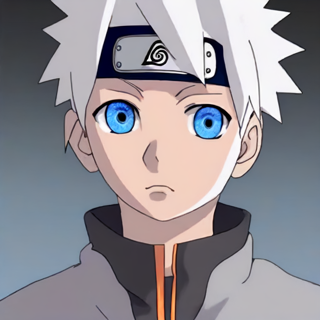

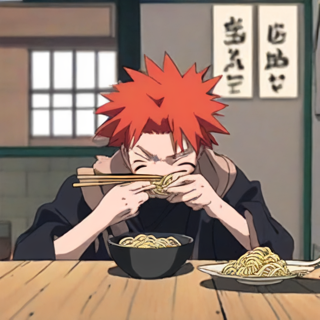

2026-08-20 08:17:51 | step 110/600 | loss 0.0968 | lr 9.99e-05 | peak VRAM 6.95 GB
INFO:train:step 110/600 | loss 0.0968 | lr 9.99e-05 | peak VRAM 6.95 GB
2026-08-20 08:18:44 | step 120/600 | loss 0.0980 | lr 9.96e-05 | peak VRAM 6.95 GB
INFO:train:step 120/600 | loss 0.0980 | lr 9.96e-05 | peak VRAM 6.95 GB
2026-08-20 08:19:36 | step 130/600 | loss 0.1014 | lr 9.91e-05 | peak VRAM 6.95 GB
INFO:train:step 130/600 | loss 0.1014 | lr 9.91e-05 | peak VRAM 6.95 GB
2026-08-20 08:20:29 | step 140/600 | loss 0.0996 | lr 9.84e-05 | peak VRAM 6.95 GB
INFO:train:step 140/600 | loss 0.0996 | lr 9.84e-05 | peak VRAM 6.95 GB
2026-08-20 08:21:21 | step 150/600 | loss 0.1084 | lr 9.76e-05 | peak VRAM 6.95 GB
INFO:train:step 150/600 | loss 0.1084 | lr 9.76e-05 | peak VRAM 6.95 GB
2026-08-20 08:22:13 | step 160/600 | loss 0.0910 | lr 9.65e-05 | peak VRAM 6.95 GB
INFO:train:step 160/600 | loss 0.0910 | lr 9.65e-05 | peak VRAM 6.95 GB
2026-08-20 08:23:05 | step 170/600 | loss 0.0916 | lr 9.52e-05 | peak 

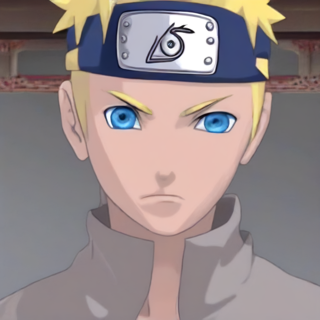

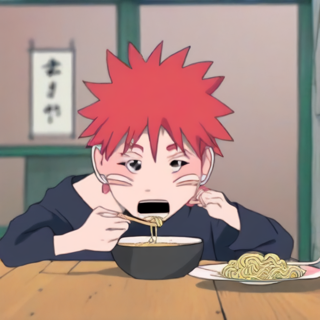

2026-08-20 08:27:05 | step 210/600 | loss 0.0900 | lr 8.85e-05 | peak VRAM 6.95 GB
INFO:train:step 210/600 | loss 0.0900 | lr 8.85e-05 | peak VRAM 6.95 GB
2026-08-20 08:27:57 | step 220/600 | loss 0.0840 | lr 8.64e-05 | peak VRAM 6.95 GB
INFO:train:step 220/600 | loss 0.0840 | lr 8.64e-05 | peak VRAM 6.95 GB
2026-08-20 08:28:50 | step 230/600 | loss 0.0762 | lr 8.42e-05 | peak VRAM 6.95 GB
INFO:train:step 230/600 | loss 0.0762 | lr 8.42e-05 | peak VRAM 6.95 GB
2026-08-20 08:29:42 | step 240/600 | loss 0.0776 | lr 8.19e-05 | peak VRAM 6.95 GB
INFO:train:step 240/600 | loss 0.0776 | lr 8.19e-05 | peak VRAM 6.95 GB
2026-08-20 08:30:34 | step 250/600 | loss 0.0721 | lr 7.94e-05 | peak VRAM 6.95 GB
INFO:train:step 250/600 | loss 0.0721 | lr 7.94e-05 | peak VRAM 6.95 GB
2026-08-20 08:31:26 | step 260/600 | loss 0.0849 | lr 7.68e-05 | peak VRAM 6.95 GB
INFO:train:step 260/600 | loss 0.0849 | lr 7.68e-05 | peak VRAM 6.95 GB
2026-08-20 08:32:19 | step 270/600 | loss 0.0824 | lr 7.41e-05 | peak 

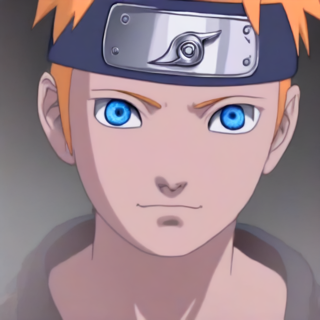

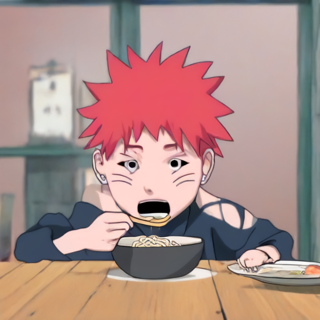

2026-08-20 08:36:14 | step 310/600 | loss 0.0845 | lr 6.24e-05 | peak VRAM 6.95 GB
INFO:train:step 310/600 | loss 0.0845 | lr 6.24e-05 | peak VRAM 6.95 GB
2026-08-20 08:37:06 | step 320/600 | loss 0.0852 | lr 5.94e-05 | peak VRAM 6.95 GB
INFO:train:step 320/600 | loss 0.0852 | lr 5.94e-05 | peak VRAM 6.95 GB
2026-08-20 08:37:59 | step 330/600 | loss 0.0847 | lr 5.63e-05 | peak VRAM 6.95 GB
INFO:train:step 330/600 | loss 0.0847 | lr 5.63e-05 | peak VRAM 6.95 GB
2026-08-20 08:38:51 | step 340/600 | loss 0.0828 | lr 5.31e-05 | peak VRAM 6.95 GB
INFO:train:step 340/600 | loss 0.0828 | lr 5.31e-05 | peak VRAM 6.95 GB
2026-08-20 08:39:43 | step 350/600 | loss 0.0878 | lr 5.00e-05 | peak VRAM 6.95 GB
INFO:train:step 350/600 | loss 0.0878 | lr 5.00e-05 | peak VRAM 6.95 GB
2026-08-20 08:40:35 | step 360/600 | loss 0.0859 | lr 4.69e-05 | peak VRAM 6.95 GB
INFO:train:step 360/600 | loss 0.0859 | lr 4.69e-05 | peak VRAM 6.95 GB
2026-08-20 08:41:27 | step 370/600 | loss 0.0828 | lr 4.37e-05 | peak 

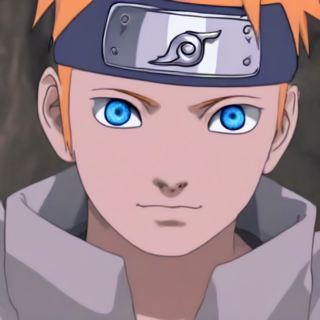

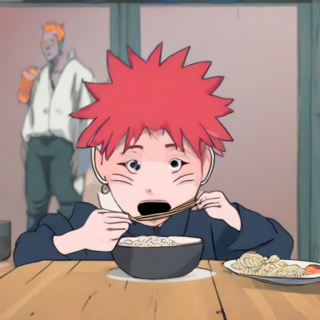

2026-08-20 08:45:24 | step 410/600 | loss 0.0741 | lr 3.16e-05 | peak VRAM 6.95 GB
INFO:train:step 410/600 | loss 0.0741 | lr 3.16e-05 | peak VRAM 6.95 GB
2026-08-20 08:46:16 | step 420/600 | loss 0.0807 | lr 2.87e-05 | peak VRAM 6.95 GB
INFO:train:step 420/600 | loss 0.0807 | lr 2.87e-05 | peak VRAM 6.95 GB
2026-08-20 08:47:08 | step 430/600 | loss 0.0835 | lr 2.59e-05 | peak VRAM 6.95 GB
INFO:train:step 430/600 | loss 0.0835 | lr 2.59e-05 | peak VRAM 6.95 GB
2026-08-20 08:48:01 | step 440/600 | loss 0.0989 | lr 2.32e-05 | peak VRAM 6.95 GB
INFO:train:step 440/600 | loss 0.0989 | lr 2.32e-05 | peak VRAM 6.95 GB
2026-08-20 08:48:53 | step 450/600 | loss 0.1059 | lr 2.06e-05 | peak VRAM 6.95 GB
INFO:train:step 450/600 | loss 0.1059 | lr 2.06e-05 | peak VRAM 6.95 GB
2026-08-20 08:49:46 | step 460/600 | loss 0.1086 | lr 1.81e-05 | peak VRAM 6.95 GB
INFO:train:step 460/600 | loss 0.1086 | lr 1.81e-05 | peak VRAM 6.95 GB
2026-08-20 08:50:39 | step 470/600 | loss 0.1088 | lr 1.58e-05 | peak 

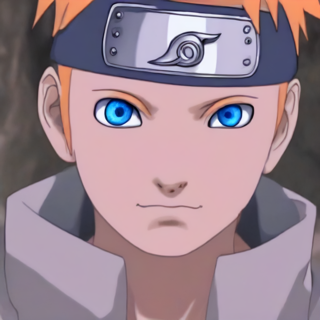

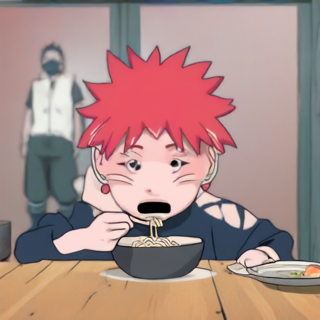

2026-08-20 08:54:39 | step 510/600 | loss 0.0922 | lr 7.78e-06 | peak VRAM 6.95 GB
INFO:train:step 510/600 | loss 0.0922 | lr 7.78e-06 | peak VRAM 6.95 GB
2026-08-20 08:55:31 | step 520/600 | loss 0.0996 | lr 6.18e-06 | peak VRAM 6.95 GB
INFO:train:step 520/600 | loss 0.0996 | lr 6.18e-06 | peak VRAM 6.95 GB
2026-08-20 08:56:23 | step 530/600 | loss 0.0975 | lr 4.76e-06 | peak VRAM 6.95 GB
INFO:train:step 530/600 | loss 0.0975 | lr 4.76e-06 | peak VRAM 6.95 GB
2026-08-20 08:57:16 | step 540/600 | loss 0.0883 | lr 3.51e-06 | peak VRAM 6.95 GB
INFO:train:step 540/600 | loss 0.0883 | lr 3.51e-06 | peak VRAM 6.95 GB
2026-08-20 08:58:09 | step 550/600 | loss 0.0869 | lr 2.45e-06 | peak VRAM 6.95 GB
INFO:train:step 550/600 | loss 0.0869 | lr 2.45e-06 | peak VRAM 6.95 GB
2026-08-20 08:59:02 | step 560/600 | loss 0.0770 | lr 1.57e-06 | peak VRAM 6.95 GB
INFO:train:step 560/600 | loss 0.0770 | lr 1.57e-06 | peak VRAM 6.95 GB
2026-08-20 08:59:55 | step 570/600 | loss 0.0641 | lr 8.86e-07 | peak 

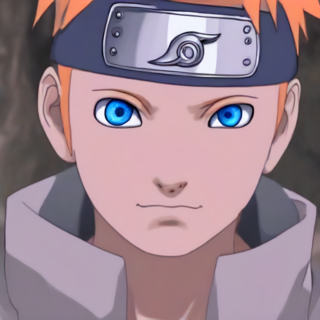

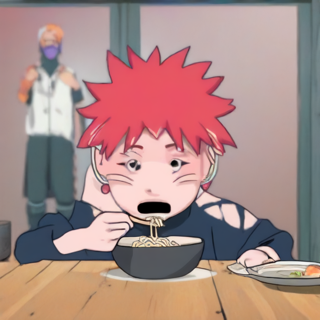

2026-08-20 09:03:04 | [ckpt] saved checkpoint-600.pt (68 MB)
INFO:train:[ckpt] saved checkpoint-600.pt (68 MB)
2026-08-20 09:03:04 | [ckpt] exported /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/lora/pytorch_lora_weights.safetensors
INFO:train:[ckpt] exported /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/lora/pytorch_lora_weights.safetensors
2026-08-20 09:03:04 | done. peak VRAM 6.95 GB
INFO:train:done. peak VRAM 6.95 GB


In [7]:
from IPython.display import display
from tqdm.auto import tqdm

imgs_per_step = cfg.train_batch_size * cfg.gradient_accumulation_steps
logger.info(f"training: {cfg.max_train_steps} steps x {imgs_per_step} imgs/step at {cfg.resolution}px "
            f"(~{cfg.max_train_steps * imgs_per_step / len(dataset):.1f} epochs)")

progress = tqdm(total=cfg.max_train_steps, initial=global_step, desc="steps")
losses, t_start, step_at_start = [], time.time(), global_step
done = global_step >= cfg.max_train_steps

while not done:
    for batch in dataloader:
        with accelerator.accumulate(unet):
            latents = batch["latents"].to(device, dtype=weight_dtype)
            prompt_embeds = batch["prompt_embeds"].to(device, dtype=weight_dtype)
            pooled = batch["pooled_embeds"].to(device, dtype=weight_dtype)
            time_ids = batch["time_ids"].to(device, dtype=weight_dtype)

            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                      (latents.shape[0],), device=device).long()
            noisy = noise_scheduler.add_noise(latents, noise, timesteps)

            pred = unet(noisy, timesteps, encoder_hidden_states=prompt_embeds,
                        added_cond_kwargs={"text_embeds": pooled, "time_ids": time_ids}).sample

            if cfg.snr_gamma > 0:
                snr = compute_snr(noise_scheduler, timesteps)
                w = torch.stack([snr, cfg.snr_gamma * torch.ones_like(snr)], dim=1).min(dim=1)[0] / snr
                loss = F.mse_loss(pred.float(), noise.float(), reduction="none")
                loss = (loss.mean(dim=list(range(1, loss.ndim))) * w).mean()
            else:
                loss = F.mse_loss(pred.float(), noise.float())

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(lora_params, cfg.max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        if accelerator.sync_gradients:
            lr_scheduler.step()
            global_step += 1
            progress.update(1)
            losses.append(loss.detach().item())

            if global_step % cfg.log_every == 0:
                avg = sum(losses[-50:]) / len(losses[-50:])
                logger.info(f"step {global_step}/{cfg.max_train_steps} | loss {avg:.4f} | "
                            f"lr {lr_scheduler.get_last_lr()[0]:.2e} | peak VRAM {vram_gb():.2f} GB")

            if global_step == 20:
                rate = (time.time() - t_start) / (global_step - step_at_start)
                eta_h = rate * (cfg.max_train_steps - global_step) / 3600
                logger.info(f"[eta] {rate:.1f}s/step -> ~{eta_h:.1f}h remaining")

            if global_step % cfg.checkpointing_steps == 0:
                save_checkpoint(global_step)
                export_lora_safetensors()

            if taesd is not None and global_step % cfg.validation_steps == 0:
                for im in render_validation_images(global_step):
                    display(im.resize((320, 320)))

            if global_step >= cfg.max_train_steps:
                done = True
                break

progress.close()
save_checkpoint(global_step)
export_lora_safetensors()
logger.info(f"done. peak VRAM {vram_gb():.2f} GB")

## 5 · Deliverables

Everything below already sits on Google Drive. Copy the final `.safetensors` and `train_log.txt` into the repo (`weights/` and `logs/`) for submission.

In [8]:
final_lora = LORA_DIR / "pytorch_lora_weights.safetensors"
print(f"LoRA weights : {final_lora} ({final_lora.stat().st_size / 2**20:.1f} MB)")
print(f"training log : {OUTPUT_DIR / 'train_log.txt'}")
print(f"checkpoints  : {sorted(p.name for p in CKPT_DIR.glob('checkpoint-*.pt'))}")
print(f"val previews : {len(list(VAL_DIR.glob('*.png')))} images in {VAL_DIR}")

# To download directly from Colab instead of via Drive, uncomment:
# from google.colab import files
# files.download(str(final_lora))
# files.download(str(OUTPUT_DIR / "train_log.txt"))

LoRA weights : /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/lora/pytorch_lora_weights.safetensors (44.5 MB)
training log : /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/train_log.txt
checkpoints  : ['checkpoint-100.pt', 'checkpoint-200.pt', 'checkpoint-300.pt', 'checkpoint-400.pt', 'checkpoint-500.pt', 'checkpoint-600.pt']
val previews : 12 images in /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/val_images


### Copy deliverables into the repo

`inference.ipynb` / `inference.py` auto-detect the Drive path, so this is only needed
to get the weights + logs into the GitHub repo for submission. Point `REPO` at your
local clone (or run this after cloning the repo inside Colab).

In [9]:
import shutil

REPO = Path("naruto-sdxl-lora-repo")  # <- your local clone of this repository

if REPO.exists():
    (REPO / "weights").mkdir(parents=True, exist_ok=True)
    (REPO / "logs").mkdir(parents=True, exist_ok=True)
    (REPO / "samples").mkdir(parents=True, exist_ok=True)
    shutil.copy(final_lora, REPO / "weights" / "pytorch_lora_weights.safetensors")
    shutil.copy(OUTPUT_DIR / "train_log.txt", REPO / "logs" / "train_log.txt")
    for p in sorted(VAL_DIR.glob("*.png")):
        shutil.copy(p, REPO / "samples" / p.name)
    print("copied weights + logs + val previews into", REPO.resolve())
else:
    print(f"{REPO} not found - copy these three by hand:")
    print("  ", final_lora, "-> weights/")
    print("  ", OUTPUT_DIR / "train_log.txt", "-> logs/")
    print("  ", VAL_DIR, "-> samples/")

naruto-sdxl-lora-repo not found - copy these three by hand:
   /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/lora/pytorch_lora_weights.safetensors -> weights/
   /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/train_log.txt -> logs/
   /content/drive/MyDrive/naruto-sdxl-lora-v2/outputs/val_images -> samples/


---
**Next:** run `inference_v2.ipynb` — note it uses **`LORA_SCALE = 1.0`**, because v2's `alpha/rank = 0.5` is already inside the adapter. Then `evaluate.py` for CLIP style / prompt-alignment numbers against v1 and base.